# CCM on SHREC Latent Coordinates vs. SINDy Residuals

**Pipeline position:** This notebook follows `02_SHREC.ipynb`, which produced the latent coordinate ψ from a four-variable SHREC run (anchovy, sardine, SST-Scripps, SST-Newport).

**What this notebook does:**
1. Load ψ directly from the pre-computed CSV (`shrec_1var_latent_coordinates.csv`).
2. Align all time series to a common calendar window.
3. Run CCM in both directions between ψ and (a) observed fish populations, (b) SINDy residuals.
4. Fit asymptotic convergence models to every CCM curve.

**Research question:**  Does the shared latent driver recovered by SHREC — a coordinate that lives on the joint attractor of all four ecosystem variables — carry causal information ?

---

**Reference:** Sugihara, G., May, R., Ye, H., Hsieh, C.-H., Deyle, E., Fogarty, M., & Munch, S. (2012).  
Detecting causality in complex ecosystems. *Science*, 338(6106), 496–500.  
DOI: [10.1126/science.1227079](https://doi.org/10.1126/science.1227079)


## Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings('ignore', category=OptimizeWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

## Helper Functions

In [12]:
def embed(ts, E, tau=1):
    """Time-delay embedding of a 1-D time series (Takens, 1981)."""
    ts = np.array(ts)
    N  = len(ts)
    embedded = np.full((N, E), np.nan)
    for i in range(E):
        shift = i * tau
        if shift == 0:
            embedded[:, i] = ts
        else:
            embedded[shift:, i] = ts[:-shift]
    return embedded


def ccm_smooth(X_raw, Y_raw, E, tau=1, L_range=None, num_samples=50):
    """
    Convergent Cross Mapping skill ρ(L) — cross-map from the shadow manifold
    of X to reconstruct Y, averaged over `num_samples` random library draws.
    """
    np.random.seed(42)
    X_raw, Y_raw = np.array(X_raw), np.array(Y_raw)
    X_emb  = embed(X_raw, E, tau)
    valid  = np.where(~np.isnan(X_emb).any(axis=1) & ~np.isnan(Y_raw))[0]

    rho_results = []
    for L in L_range:
        rho_L = []
        for _ in range(num_samples):
            lib_idx = np.random.choice(valid, size=L, replace=False)
            tree    = cKDTree(X_emb[lib_idx])
            dists, inds = tree.query(X_emb[valid], k=E + 2)

            y_preds, y_actuals = [], []
            for i, t in enumerate(valid):
                mask = (lib_idx[inds[i]] != t)
                nn_idx   = inds[i][mask][:E + 1]
                nn_dists = dists[i][mask][:E + 1]
                if len(nn_idx) < E + 1:
                    continue
                d1 = nn_dists[0]
                w  = (nn_dists == 0).astype(float) if d1 == 0 else np.exp(-nn_dists / d1)
                w /= w.sum()
                y_preds.append(np.dot(w, Y_raw[lib_idx[nn_idx]]))
                y_actuals.append(Y_raw[t])

            if len(y_preds) > 1:
                rho_L.append(pearsonr(y_preds, y_actuals)[0])
            else:
                rho_L.append(np.nan)

        rho_results.append(np.nanmean(rho_L))

    return np.array(L_range), np.maximum(0, rho_results)


def convergence_model(L, alpha, gamma, rho_inf):
    """Exponential convergence model: ρ(L) = α · exp(−γL) + ρ∞."""
    return alpha * np.exp(-gamma * L) + rho_inf


def fit_convergence(L_range, rho_data, label, ax=None, color='steelblue'):
    """
    Fit ρ(L) = α·exp(−γL) + ρ∞ and report the asymptotic cross-map skill ρ∞.
    Plots the fit curve on `ax` when provided.
    """
    rho_data = np.asarray(rho_data)
    finite   = np.isfinite(rho_data)
    if finite.sum() < 4:
        print(f"  {label:55} | ⚠ too few finite points")
        return None
    Lf, rf = L_range[finite].astype(float), rho_data[finite]
    try:
        p0     = [rf.min() - rf.max(), 0.05, rf.max()]
        bounds = ([-np.inf, 0, 0], [np.inf, np.inf, 1.0])
        popt, _ = curve_fit(convergence_model, Lf, rf,
                            p0=p0, bounds=bounds, maxfev=10_000)
        alpha, gamma, rho_inf = popt
        if gamma < 1e-4 or abs(alpha) < 1e-4:
            verdict = "➡  flat / no convergence"
        else:
            verdict = f"ρ∞ = {rho_inf:.3f}   (γ = {gamma:.4f})"
        print(f"  {label:55} | {verdict}")
        if ax is not None:
            L_ext = np.linspace(Lf[0], Lf[-1] * 1.5, 300)
            ax.plot(L_ext, convergence_model(L_ext, *popt),
                    '--', color=color, lw=1.5, label=f'fit  ρ∞={rho_inf:.3f}')
        return rho_inf
    except RuntimeError:
        print(f"  {label:55} | fit did not converge")
        return None


def safe_L_range(series_list, E, tau, margin=1):
    """Largest usable CCM library range for a collection of time series."""
    n_valid = min(
        int(np.sum(~np.isnan(embed(s, E, tau)).any(axis=1)))
        for s in series_list
    )
    return np.arange(10, n_valid - margin, 2)

---
## Load Data

### Ecological time series

Annual landings and SST records (1929–2006, N = 78).  The file `sardine_anchovy_sst.csv` is a CSV export of the original `sardine_anchovy_sst.RData` from Sugihara et al. (2012).  See `01_CCM_Sugihara_Replication.ipynb` for column descriptions.

In [3]:
df_eco = pd.read_csv('sardine_anchovy_sst.csv')
df_eco['year'] = pd.to_datetime(df_eco['year'].astype(str), format='%Y')
df_eco = df_eco.sort_values('year').set_index('year').interpolate(method='linear')
df_eco_norm = (df_eco - df_eco.mean()) / df_eco.std()

years        = df_eco.index.year.values
sardine      = df_eco_norm['sardine'].values
anchovy      = df_eco_norm['anchovy'].values
sst_scripps  = df_eco_norm['sio_sst'].values
sst_newport  = df_eco_norm['np_sst'].values

print(f"Ecological data loaded: {len(years)} annual observations ({years[0]}–{years[-1]})")

Ecological data loaded: 78 annual observations (1929–2006)


### SHREC latent coordinate ψ

ψ loaded: 76 time points (1931–2006)


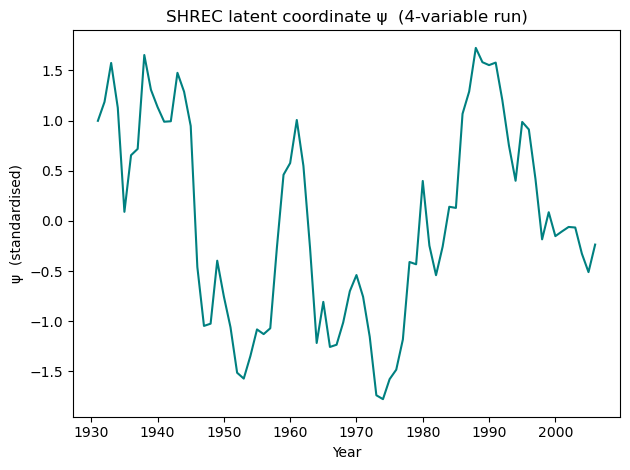

In [5]:
df_psi  = pd.read_csv('shrec_1var_latent_coordinates.csv')
psi_1   = df_psi['Psi_1_Standardized'].values   # already z-scored
years_shrec = df_psi['Year'].values

print(f"ψ loaded: {len(psi_1)} time points ({years_shrec[0]}–{years_shrec[-1]})")

plt.plot(years_shrec, psi_1, color='teal', lw=1.5)
plt.xlabel('Year')
plt.ylabel('ψ  (standardised)')
plt.title('SHREC latent coordinate ψ  (4-variable run)')

plt.tight_layout()
plt.show()

---
## CCM between ψ and Fish Populations

Does the SHREC latent coordinate have a causal relationship with the observed fish populations?  By the CCM convention, a significant and *converging* ρ(L) for direction "X xmap Y" means X's shadow manifold can reconstruct Y — evidence that Y causally influences X.

In [7]:
E_ccm, tau_ccm = 3, 1

L_step1 = safe_L_range(
    [psi_1, sardine_aligned, anchovy_aligned], E_ccm, tau_ccm)
print(f"Step 1  —  L_range: {L_step1[0]}–{L_step1[-1]}  ({len(L_step1)} values)")
print("Running 4 CCM directions …")

L1, rho_sard_xmap_psi1 = ccm_smooth(sardine_aligned, psi_1, E_ccm, tau_ccm, L_step1)
_,  rho_psi1_xmap_sard = ccm_smooth(psi_1, sardine_aligned, E_ccm, tau_ccm, L_step1)
_,  rho_anch_xmap_psi1 = ccm_smooth(anchovy_aligned, psi_1, E_ccm, tau_ccm, L_step1)
_,  rho_psi1_xmap_anch = ccm_smooth(psi_1, anchovy_aligned, E_ccm, tau_ccm, L_step1)

print("Done.")

Step 1  —  L_range: 10–72  (32 values)
Running 4 CCM directions …
Done.


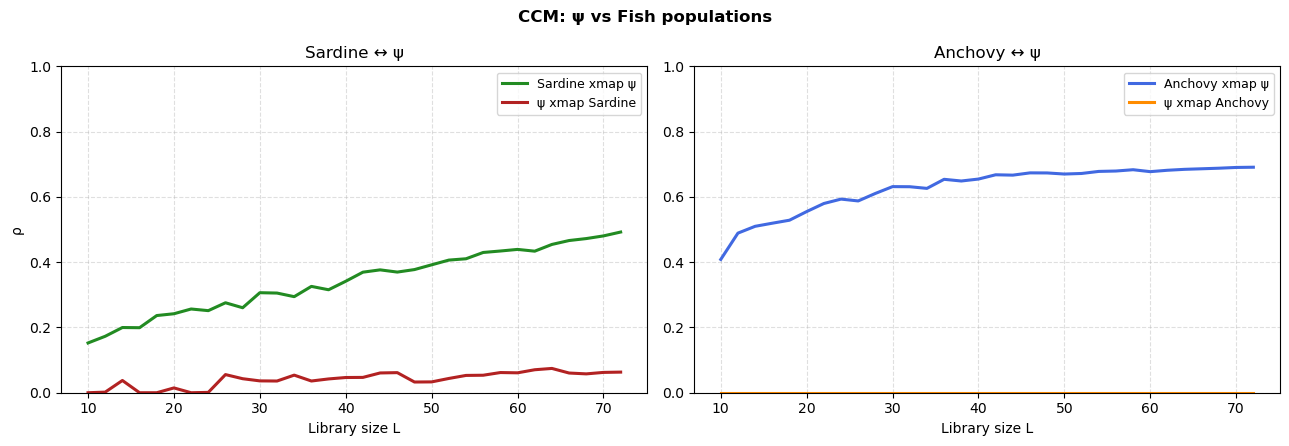

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('CCM: ψ vs Fish populations', fontsize=12, fontweight='bold')

kw = dict(lw=2.2)
axes[0].plot(L1, rho_sard_xmap_psi1, color='forestgreen', **kw, label='Sardine xmap ψ')
axes[0].plot(L1, rho_psi1_xmap_sard, color='firebrick',   **kw, label='ψ xmap Sardine')
axes[0].set(title='Sardine ↔ ψ', xlabel='Library size L', ylabel='ρ', ylim=(0, 1))
axes[0].legend(fontsize=9); axes[0].grid(ls='--', alpha=0.4)

axes[1].plot(L1, rho_anch_xmap_psi1, color='royalblue',   **kw, label='Anchovy xmap ψ')
axes[1].plot(L1, rho_psi1_xmap_anch, color='darkorange',  **kw, label='ψ xmap Anchovy')
axes[1].set(title='Anchovy ↔ ψ', xlabel='Library size L', ylim=(0, 1))
axes[1].legend(fontsize=9); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
## Convergence Analysis

Each CCM curve is fitted to ρ(L) = α · exp(−γL) + ρ∞.  
- **ρ∞ > 0.3 with finite γ** → genuine causal signal that grows with library size.  
- **Flat / γ ≈ 0** → no detectable causal linkage.

CONVERGENCE ANALYSIS — all CCM curves

Sardine ↔ ψ:
  Sardine xmap ψ                                          | ρ∞ = 0.887   (γ = 0.0095)
  ψ xmap Sardine                                          | ρ∞ = 0.079   (γ = 0.0274)

Anchovy ↔ ψ:
  Anchovy xmap ψ                                          | ρ∞ = 0.692   (γ = 0.0663)
  ψ xmap Anchovy                                          | ➡  flat / no convergence


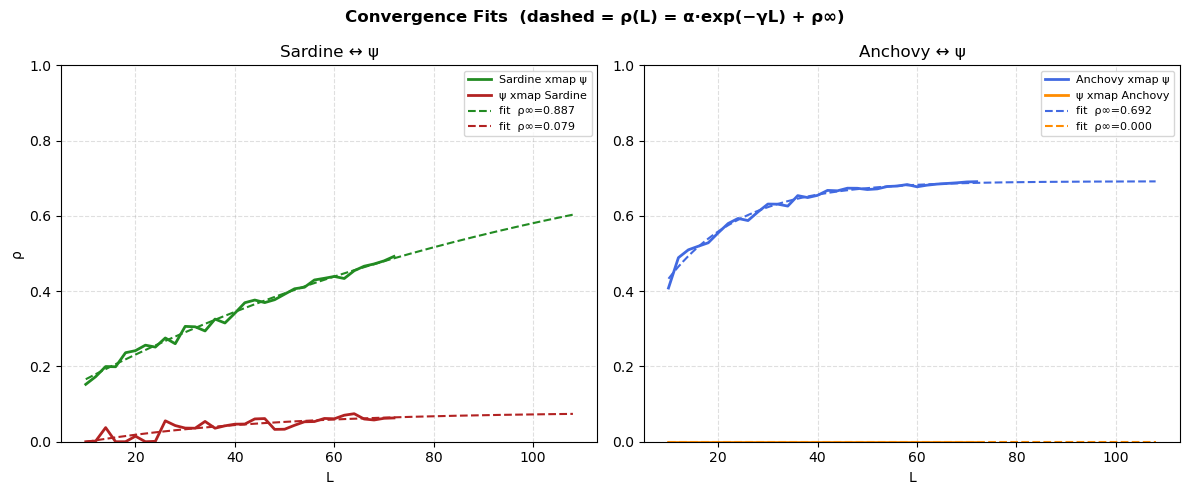


Interpretation guide:
  ρ∞ > 0.3  +  finite γ   →  genuine causal signal
  flat / γ ≈ 0            →  no detectable causal linkage


In [13]:
print("=" * 70)
print("CONVERGENCE ANALYSIS — all CCM curves")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Convergence Fits  (dashed = ρ(L) = α·exp(−γL) + ρ∞)',
             fontsize=12, fontweight='bold')

# Panel 1 — Sardine ↔ ψ
print("\nSardine ↔ ψ:")
ax = axes[0]
ax.plot(L1, rho_sard_xmap_psi1, color='forestgreen', lw=2, label='Sardine xmap ψ')
ax.plot(L1, rho_psi1_xmap_sard, color='firebrick',   lw=2, label='ψ xmap Sardine')
fit_convergence(L1, rho_sard_xmap_psi1, 'Sardine xmap ψ', ax, 'forestgreen')
fit_convergence(L1, rho_psi1_xmap_sard, 'ψ xmap Sardine', ax, 'firebrick')
ax.set(title='Sardine ↔ ψ', xlabel='L', ylabel='ρ', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

# Panel 2 — Anchovy ↔ ψ
print("\nAnchovy ↔ ψ:")
ax = axes[1]
ax.plot(L1, rho_anch_xmap_psi1, color='royalblue',  lw=2, label='Anchovy xmap ψ')
ax.plot(L1, rho_psi1_xmap_anch, color='darkorange', lw=2, label='ψ xmap Anchovy')
fit_convergence(L1, rho_anch_xmap_psi1, 'Anchovy xmap ψ', ax, 'royalblue')
fit_convergence(L1, rho_psi1_xmap_anch, 'ψ xmap Anchovy', ax, 'darkorange')
ax.set(title='Anchovy ↔ ψ', xlabel='L', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)


plt.tight_layout()
plt.show()

print()
print("Interpretation guide:")
print("  ρ∞ > 0.3  +  finite γ   →  genuine causal signal")
print("  flat / γ ≈ 0            →  no detectable causal linkage")

---
## CCM between ψ and SSTs

The SHREC run that produced ψ used *all four* ecosystem variables — anchovy, sardine, SST-Scripps, and SST-Newport.  The SSTs therefore contributed to the manifold geometry from which ψ was derived.  This section asks whether the cross-map skill between ψ and each SST record genuinely *converges*, and whether the two directions are asymmetric — an asymmetry that would signal directional causal influence rather than shared embedding structure.

**Pairs tested:**
- ψ ↔ SST-Scripps (`sio_sst`)
- ψ ↔ SST-Newport (`np_sst`)


In [15]:
# Align SSTs to the same ψ window (1931–2006, length 76)
sst_scripps_aligned = sst_scripps[shrec_start:]
sst_newport_aligned  = sst_newport[shrec_start:]

assert len(sst_scripps_aligned) == len(psi_1), (
    f"Length mismatch: SST-Scripps = {len(sst_scripps_aligned)}, ψ = {len(psi_1)}")
assert len(sst_newport_aligned) == len(psi_1), (
    f"Length mismatch: SST-Newport  = {len(sst_newport_aligned)}, ψ = {len(psi_1)}")

L_step3 = safe_L_range(
    [psi_1, sst_scripps_aligned, sst_newport_aligned], E_ccm, tau_ccm)
print(f"Step 3  —  L_range: {L_step3[0]}–{L_step3[-1]}  ({len(L_step3)} values)")
print("Running 4 CCM directions …")

L3, rho_sst_s_xmap_psi1 = ccm_smooth(sst_scripps_aligned, psi_1,             E_ccm, tau_ccm, L_step3)
_,  rho_psi1_xmap_sst_s = ccm_smooth(psi_1,             sst_scripps_aligned, E_ccm, tau_ccm, L_step3)
_,  rho_sst_n_xmap_psi1 = ccm_smooth(sst_newport_aligned,  psi_1,            E_ccm, tau_ccm, L_step3)
_,  rho_psi1_xmap_sst_n = ccm_smooth(psi_1,             sst_newport_aligned,  E_ccm, tau_ccm, L_step3)

print("Done.")


Step 3  —  L_range: 10–72  (32 values)
Running 4 CCM directions …
Done.


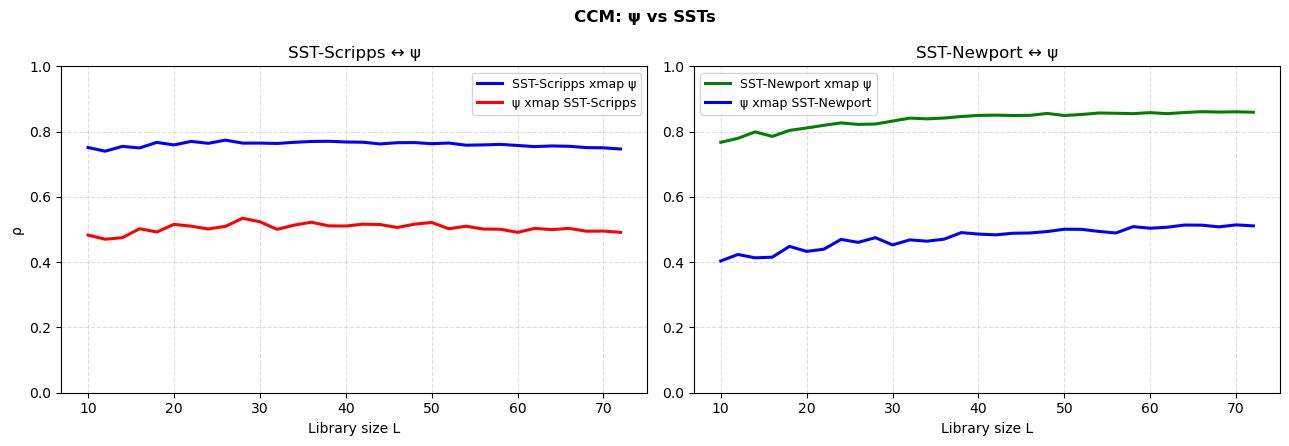

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('CCM: ψ vs SSTs', fontsize=12, fontweight='bold')

kw = dict(lw=2.2)

# Scripps
axes[0].plot(L3, rho_sst_s_xmap_psi1, color='b',   **kw, label='SST-Scripps xmap ψ')
axes[0].plot(L3, rho_psi1_xmap_sst_s, color='r',      **kw, label='ψ xmap SST-Scripps')
axes[0].set(title='SST-Scripps ↔ ψ', xlabel='Library size L', ylabel='ρ', ylim=(0, 1))
axes[0].legend(fontsize=9); axes[0].grid(ls='--', alpha=0.4)

# Newport
axes[1].plot(L3, rho_sst_n_xmap_psi1, color='g', **kw, label='SST-Newport xmap ψ')
axes[1].plot(L3, rho_psi1_xmap_sst_n, color='b',    **kw, label='ψ xmap SST-Newport')
axes[1].set(title='SST-Newport ↔ ψ', xlabel='Library size L', ylim=(0, 1))
axes[1].legend(fontsize=9); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()


---
## Convergence Analysis — ψ vs SSTs

As in the previous sections, each curve is fitted to ρ(L) = α · exp(−γL) + ρ∞.  
The asymptotic skill ρ∞ summarises whether the cross-map signal grows with library size (genuine causality) or remains flat (spurious correlation from shared embedding).


CONVERGENCE ANALYSIS — ψ vs SSTs

SST-Scripps ↔ ψ:
  SST-Scripps xmap ψ                                      | ρ∞ = 0.762   (γ = 0.2286)
  ψ xmap SST-Scripps                                      | ρ∞ = 0.508   (γ = 0.1940)

SST-Newport ↔ ψ:
  SST-Newport xmap ψ                                      | ρ∞ = 0.862   (γ = 0.0590)
  ψ xmap SST-Newport                                      | ρ∞ = 0.528   (γ = 0.0337)


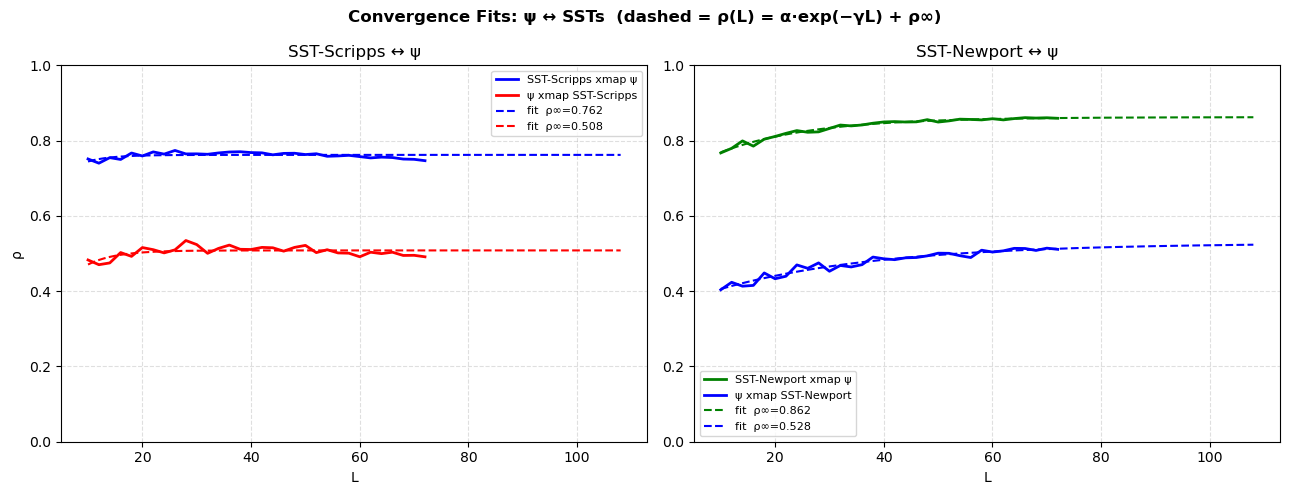


Interpretation guide:
  ρ∞ > 0.3  +  finite γ   →  genuine causal signal
  flat / γ ≈ 0            →  no detectable causal linkage

Note: both SSTs were included in the SHREC manifold construction,
so some baseline cross-map skill is expected from shared geometry.
Asymmetry between the two directions is the key diagnostic.


In [19]:
print("=" * 70)
print("CONVERGENCE ANALYSIS — ψ vs SSTs")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Convergence Fits: ψ ↔ SSTs  (dashed = ρ(L) = α·exp(−γL) + ρ∞)',
             fontsize=12, fontweight='bold')

# Panel 1 — SST-Scripps ↔ ψ
print("\nSST-Scripps ↔ ψ:")
ax = axes[0]
ax.plot(L3, rho_sst_s_xmap_psi1, color='b',   lw=2, label='SST-Scripps xmap ψ')
ax.plot(L3, rho_psi1_xmap_sst_s, color='r',      lw=2, label='ψ xmap SST-Scripps')
fit_convergence(L3, rho_sst_s_xmap_psi1, 'SST-Scripps xmap ψ',  ax, 'b')
fit_convergence(L3, rho_psi1_xmap_sst_s, 'ψ xmap SST-Scripps',  ax, 'r')
ax.set(title='SST-Scripps ↔ ψ', xlabel='L', ylabel='ρ', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

# Panel 2 — SST-Newport ↔ ψ
print("\nSST-Newport ↔ ψ:")
ax = axes[1]
ax.plot(L3, rho_sst_n_xmap_psi1, color='g', lw=2, label='SST-Newport xmap ψ')
ax.plot(L3, rho_psi1_xmap_sst_n, color='b',    lw=2, label='ψ xmap SST-Newport')
fit_convergence(L3, rho_sst_n_xmap_psi1, 'SST-Newport xmap ψ',   ax, 'g')
fit_convergence(L3, rho_psi1_xmap_sst_n, 'ψ xmap SST-Newport',   ax, 'b')
ax.set(title='SST-Newport ↔ ψ', xlabel='L', ylim=(0, 1))
ax.legend(fontsize=8); ax.grid(ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

print()
print("Interpretation guide:")
print("  ρ∞ > 0.3  +  finite γ   →  genuine causal signal")
print("  flat / γ ≈ 0            →  no detectable causal linkage")
print()
print("Note: both SSTs were included in the SHREC manifold construction,")
print("so some baseline cross-map skill is expected from shared geometry.")
print("Asymmetry between the two directions is the key diagnostic.")
